# District Heating MILP — Oracle V(SoC) Upper Bound

**Purpose.** Step 1 of the V(SoC) evaluation from GitHub issue #36: measure the *theoretical upper bound* of adding a terminal value function to MPC-35h. Without an electricity-price forecast we can't push the horizon past 35h, so V(SoC) is the only remaining lever for the €113.7/day residual gap between MPC-35h and the perfect-foresight ceiling.

The question this notebook answers: **if V(SoC) could be learned perfectly, how much of that residual gap would it close?** If the oracle closes most of it, learning V is worth pursuing (Step 2). If it barely moves the needle, V is not the right lever and we stop.

## Design

- **Oracle V at solve-day D.** At the 35h commit boundary (= 00:00 Berlin D+2), sweep a SoC grid `{0, 50, 100, 150, 200}`. For each anchor `s`, run a perfect-foresight MILP over `forward_days` with SoC=s and default unit state (all off, TIS_LONG). The resulting objective is the cost-to-go `V_D(s)`.
- **Concave-hull projection.** The sampled (s, V_D(s)) pairs are projected onto the lower convex envelope so the PWL injected into MPC is guaranteed convex. Non-convexities from MILP gap / integer effects get absorbed; this is what an LP-relaxation V would look like.
- **MPC-35h + V.** `build_model` gets an optional `terminal_pwl=(breakpoints, values)` argument that adds `+V_term` to the objective, with `V_term = PWL(SoC[T])` enforced via `pyo.Piecewise` (SOS2, EQ).
- **Baselines** come from the already-computed `mpc_year2_results.pkl` — MPC-35h and ceiling per-day costs on the same dates, no recomputation.

## Known limitations (upper bound = optimistic)

1. **Perfect foresight used to build V.** A learned V can only be worse. This notebook gives an upper bound, not a deployable strategy.
2. **V depends on SoC only.** The unit-state carryover (boiler/CHP on/off + time-in-state) at the anchor is fixed to default. Error bound: ~1 CHP startup (€600) per solve-day.
3. **Forward window is finite** (`forward_days`, default 10d). Any value locked up past that window is invisible to V. Longer forward → tighter bound but slower runtime.
4. **Convex-hull projection may discard small local gains** near the value-function "kinks" caused by integer decisions.

## Scope (Step 1)

One winter stretch from year 2 pickle, 5-point SoC grid, `forward_days=10`. Goal: one headline number — `gap_recovered_by_oracle_V`. That number gates Step 2.


In [1]:
import sys
import pickle
from dataclasses import dataclass
from datetime import date, timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyomo.environ as pyo
import pyomo

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 110

BERLIN = 'Europe/Berlin'
PRICE_COLUMN = 'Deutschland/Luxemburg [€/MWh] Berechnete Auflösungen'
print('pyomo', pyomo.__version__, '| pandas', pd.__version__)


pyomo 6.10.0 | pandas 3.0.2


## 1. Model, solver, dispatch/state extraction

Same dispatch MILP as `mpc_prototype.ipynb`, with one addition: `build_model(..., terminal_pwl=(bps, vals))` attaches a terminal-cost term `+V_term` to the minimization objective.

**Injection method.** After the convex-hull projection (next section) the PWL is guaranteed convex. For convex PWL in a minimization, the cleanest encoding is a set of linear lower bounds — one per segment — no SOS2, no extra binaries, just LP:

```
V_term >= a_i · SoC[T] + b_i     for each hull segment i
```

where `(a_i, b_i)` is the slope/intercept of segment `i`. Minimization pushes `V_term` down to the max of those lines, which equals the convex PWL value at `SoC[T]`. This encoding is tight and keeps the MILP LP-relaxation strong.

We validate with a guard: the input `vals` must be convex (checked via the hull projection already being applied before calling `build_model`). A convexity assertion inside `build_model` catches accidental mis-use.


In [2]:
PARAMS = {
    'dt': 0.25,
    'gas_price': 35.0, 'co2_factor': 0.201, 'co2_price': 60.0,
    'sto_capacity': 200.0, 'sto_charge_max': 15.0, 'sto_discharge_max': 15.0,
    'sto_loss': 0.000125, 'sto_soc_init': 200.0,
    'hp_p_el_max': 8.0, 'hp_p_el_min': 1.0, 'hp_cop': 3.5,
    'boiler_q_max': 12.0, 'boiler_q_min': 2.0, 'boiler_eff': 0.97,
    'boiler_min_up': 4, 'boiler_min_down': 4,
    'chp_p_el_max': 6.0, 'chp_p_el_min': 2.0,
    'chp_eff_el': 0.4, 'chp_eff_th': 0.48,
    'chp_min_up': 8, 'chp_min_down': 8, 'chp_startup_cost': 600.0,
}
PARAMS['gas_cost'] = PARAMS['gas_price'] + PARAMS['co2_factor'] * PARAMS['co2_price']
PARAMS['chp_heat_power_ratio'] = PARAMS['chp_eff_th'] / PARAMS['chp_eff_el']

TIS_LONG = 999

def default_initial_states() -> dict:
    return {
        'z_hp_0': 0, 'z_boiler_0': 0, 'z_chp_0': 0,
        'boiler_time_in_state_0': TIS_LONG,
        'chp_time_in_state_0': TIS_LONG,
        'soc_0': PARAMS['sto_soc_init'],
    }

def build_model(demand_mw, price_eur, initial_states=None, terminal_pwl=None):
    """Dispatch MILP over arbitrary hourly horizon. T = len(demand_mw)*4.

    terminal_pwl : optional (bps, vals). Must be a CONVEX PWL (non-decreasing slopes).
        Injects +V_term into the objective where V_term >= a_i * SoC[T] + b_i for each
        segment i of the PWL. In a minimization, V_term = the PWL value at SoC[T].
        bps must be strictly increasing and cover [0, 200].
    """
    if len(demand_mw) != len(price_eur):
        raise ValueError('demand and price must be same length')
    if len(demand_mw) == 0:
        raise ValueError('empty horizon')

    p = PARAMS
    dt = p['dt']
    T = len(demand_mw) * 4
    demand_15 = np.repeat(np.asarray(demand_mw, float), 4)
    price_15 = np.repeat(np.asarray(price_eur, float), 4)

    if initial_states is None:
        initial_states = default_initial_states()
    soc_init = initial_states.get('soc_0', p['sto_soc_init'])

    m = pyo.ConcreteModel('DistrictHeatingMILP')
    m.T_set = pyo.RangeSet(1, T)
    m.demand = pyo.Param(m.T_set, initialize={t: demand_15[t-1] for t in range(1, T+1)})
    m.da_price = pyo.Param(m.T_set, initialize={t: price_15[t-1] for t in range(1, T+1)})

    m.z_hp = pyo.Var(m.T_set, within=pyo.Binary)
    m.P_hp_el = pyo.Var(m.T_set, within=pyo.NonNegativeReals, bounds=(0, p['hp_p_el_max']))
    m.Q_hp = pyo.Var(m.T_set, within=pyo.NonNegativeReals)

    m.z_boiler = pyo.Var(m.T_set, within=pyo.Binary)
    m.s_boiler = pyo.Var(m.T_set, within=pyo.Binary)
    m.d_boiler = pyo.Var(m.T_set, within=pyo.Binary)
    m.Q_boiler = pyo.Var(m.T_set, within=pyo.NonNegativeReals, bounds=(0, p['boiler_q_max']))
    m.F_boiler = pyo.Var(m.T_set, within=pyo.NonNegativeReals)

    m.z_chp = pyo.Var(m.T_set, within=pyo.Binary)
    m.s_chp = pyo.Var(m.T_set, within=pyo.Binary)
    m.d_chp = pyo.Var(m.T_set, within=pyo.Binary)
    m.P_chp_el = pyo.Var(m.T_set, within=pyo.NonNegativeReals, bounds=(0, p['chp_p_el_max']))
    m.Q_chp = pyo.Var(m.T_set, within=pyo.NonNegativeReals)
    m.F_chp = pyo.Var(m.T_set, within=pyo.NonNegativeReals)

    m.y_sto = pyo.Var(m.T_set, within=pyo.Binary)
    m.Q_charge = pyo.Var(m.T_set, within=pyo.NonNegativeReals, bounds=(0, p['sto_charge_max']))
    m.Q_discharge = pyo.Var(m.T_set, within=pyo.NonNegativeReals, bounds=(0, p['sto_discharge_max']))
    m.SoC = pyo.Var(pyo.RangeSet(0, T), within=pyo.NonNegativeReals, bounds=(0, p['sto_capacity']))

    # Terminal value (optional): LP encoding of a convex PWL
    if terminal_pwl is not None:
        bps, vals = terminal_pwl
        bps = [float(b) for b in bps]
        vals = [float(v) for v in vals]
        if len(bps) < 2 or len(bps) != len(vals):
            raise ValueError('terminal_pwl: need >=2 points, bps/vals same length')
        if any(bps[i] >= bps[i+1] for i in range(len(bps)-1)):
            raise ValueError('terminal_pwl: breakpoints must be strictly increasing')
        if bps[0] > 1e-9 or bps[-1] < p['sto_capacity'] - 1e-9:
            raise ValueError(f'terminal_pwl: breakpoints must cover [0, {p["sto_capacity"]}]')
        # Convexity check: slopes non-decreasing (less negative → more positive).
        slopes = [(vals[i+1]-vals[i])/(bps[i+1]-bps[i]) for i in range(len(bps)-1)]
        for i in range(len(slopes)-1):
            if slopes[i+1] < slopes[i] - 1e-6:
                raise ValueError(
                    f'terminal_pwl non-convex at seg {i}: slopes {slopes[i]:.3f} -> {slopes[i+1]:.3f}. '
                    f'Project onto lower convex envelope before calling build_model.')
        # Introduce V_term and lower-bound constraints per segment.
        m.V_term = pyo.Var(domain=pyo.Reals)
        # V_term >= a_i * SoC[T] + b_i  with b_i = vals[i] - slopes[i]*bps[i]
        m.V_seg = pyo.ConstraintList()
        for i, a_i in enumerate(slopes):
            b_i = vals[i] - a_i * bps[i]
            m.V_seg.add(m.V_term >= a_i * m.SoC[T] + b_i)

    def obj_rule(mdl):
        base = sum(
            mdl.P_hp_el[t]*mdl.da_price[t]*dt
            + mdl.F_boiler[t]*p['gas_cost']*dt
            + mdl.F_chp[t]*p['gas_cost']*dt
            + p['chp_startup_cost']*mdl.s_chp[t]
            - mdl.P_chp_el[t]*mdl.da_price[t]*dt
            for t in mdl.T_set)
        if terminal_pwl is not None:
            return base + mdl.V_term
        return base
    m.obj = pyo.Objective(rule=obj_rule, sense=pyo.minimize)

    m.energy_balance = pyo.Constraint(m.T_set, rule=lambda m,t:
        m.Q_hp[t]+m.Q_boiler[t]+m.Q_chp[t]+m.Q_discharge[t]-m.Q_charge[t] == m.demand[t])
    m.soc_init = pyo.Constraint(expr=m.SoC[0] == soc_init)
    m.charge_excl = pyo.Constraint(m.T_set, rule=lambda m,t: m.Q_charge[t] <= p['sto_charge_max']*m.y_sto[t])
    m.discharge_excl = pyo.Constraint(m.T_set, rule=lambda m,t: m.Q_discharge[t] <= p['sto_discharge_max']*(1-m.y_sto[t]))
    m.soc_dyn = pyo.Constraint(m.T_set, rule=lambda m,t:
        m.SoC[t] == m.SoC[t-1] + m.Q_charge[t]*dt - m.Q_discharge[t]*dt - p['sto_loss'])

    m.hp_min = pyo.Constraint(m.T_set, rule=lambda m,t: m.P_hp_el[t] >= p['hp_p_el_min']*m.z_hp[t])
    m.hp_max = pyo.Constraint(m.T_set, rule=lambda m,t: m.P_hp_el[t] <= p['hp_p_el_max']*m.z_hp[t])
    m.hp_th = pyo.Constraint(m.T_set, rule=lambda m,t: m.Q_hp[t] == p['hp_cop']*m.P_hp_el[t])

    m.b_min = pyo.Constraint(m.T_set, rule=lambda m,t: m.Q_boiler[t] >= p['boiler_q_min']*m.z_boiler[t])
    m.b_max = pyo.Constraint(m.T_set, rule=lambda m,t: m.Q_boiler[t] <= p['boiler_q_max']*m.z_boiler[t])
    m.b_fuel = pyo.Constraint(m.T_set, rule=lambda m,t: m.F_boiler[t] == m.Q_boiler[t]/p['boiler_eff'])

    z_b0 = initial_states['z_boiler_0']
    b_tis = initial_states.get('boiler_time_in_state_0', TIS_LONG)
    if z_b0 == 1 and b_tis < p['boiler_min_up']:
        for t in range(1, min(p['boiler_min_up']-b_tis+1, T+1)): m.z_boiler[t].fix(1)
    elif z_b0 == 0 and b_tis < p['boiler_min_down']:
        for t in range(1, min(p['boiler_min_down']-b_tis+1, T+1)): m.z_boiler[t].fix(0)
    m.b_start = pyo.Constraint(m.T_set, rule=lambda m,t:
        m.s_boiler[t] >= m.z_boiler[t] - (z_b0 if t==1 else m.z_boiler[t-1]))
    m.b_shut = pyo.Constraint(m.T_set, rule=lambda m,t:
        m.d_boiler[t] >= (z_b0 if t==1 else m.z_boiler[t-1]) - m.z_boiler[t])
    Lub, Ldb = p['boiler_min_up'], p['boiler_min_down']
    m.b_minup = pyo.Constraint(m.T_set, rule=lambda m,t:
        sum(m.s_boiler[i] for i in range(max(1,t-Lub+1), t+1)) <= m.z_boiler[t])
    m.b_mindn = pyo.Constraint(m.T_set, rule=lambda m,t:
        sum(m.d_boiler[i] for i in range(max(1,t-Ldb+1), t+1)) <= 1 - m.z_boiler[t])

    m.c_min = pyo.Constraint(m.T_set, rule=lambda m,t: m.P_chp_el[t] >= p['chp_p_el_min']*m.z_chp[t])
    m.c_max = pyo.Constraint(m.T_set, rule=lambda m,t: m.P_chp_el[t] <= p['chp_p_el_max']*m.z_chp[t])
    m.c_th = pyo.Constraint(m.T_set, rule=lambda m,t: m.Q_chp[t] == p['chp_heat_power_ratio']*m.P_chp_el[t])
    m.c_fuel = pyo.Constraint(m.T_set, rule=lambda m,t: m.F_chp[t] == m.P_chp_el[t]/p['chp_eff_el'])

    z_c0 = initial_states['z_chp_0']
    c_tis = initial_states.get('chp_time_in_state_0', TIS_LONG)
    if z_c0 == 1 and c_tis < p['chp_min_up']:
        for t in range(1, min(p['chp_min_up']-c_tis+1, T+1)): m.z_chp[t].fix(1)
    elif z_c0 == 0 and c_tis < p['chp_min_down']:
        for t in range(1, min(p['chp_min_down']-c_tis+1, T+1)): m.z_chp[t].fix(0)
    m.c_start = pyo.Constraint(m.T_set, rule=lambda m,t:
        m.s_chp[t] >= m.z_chp[t] - (z_c0 if t==1 else m.z_chp[t-1]))
    m.c_shut = pyo.Constraint(m.T_set, rule=lambda m,t:
        m.d_chp[t] >= (z_c0 if t==1 else m.z_chp[t-1]) - m.z_chp[t])
    Luc, Ldc = p['chp_min_up'], p['chp_min_down']
    m.c_minup = pyo.Constraint(m.T_set, rule=lambda m,t:
        sum(m.s_chp[i] for i in range(max(1,t-Luc+1), t+1)) <= m.z_chp[t])
    m.c_mindn = pyo.Constraint(m.T_set, rule=lambda m,t:
        sum(m.d_chp[i] for i in range(max(1,t-Ldc+1), t+1)) <= 1 - m.z_chp[t])

    m._init_states = dict(initial_states)
    m._T = T
    m._has_terminal_pwl = terminal_pwl is not None
    return m

def solve_model(model, time_limit=300, mip_gap=None):
    solver = pyo.SolverFactory('appsi_highs')
    solver.options['time_limit'] = time_limit
    if mip_gap is not None:
        solver.options['mip_rel_gap'] = mip_gap
    res = solver.solve(model, tee=False)
    status = res.solver.termination_condition
    feas = status in (pyo.TerminationCondition.optimal, pyo.TerminationCondition.feasible)
    return {'feasible': feas, 'status': str(status),
            'objective': pyo.value(model.obj) if feas else None}

def extract_dispatch(model, t_start=1, t_end=None):
    T = model._T
    if t_end is None: t_end = T
    p = PARAMS; dt = p['dt']
    ts = list(range(t_start, t_end+1))
    g = lambda v,i: pyo.value(v[i])
    hp_p_el = [g(model.P_hp_el,t) for t in ts]
    boiler_q = [g(model.Q_boiler,t) for t in ts]
    chp_p_el = [g(model.P_chp_el,t) for t in ts]
    chp_q = [g(model.Q_chp,t) for t in ts]
    s_chp = [int(round(g(model.s_chp,t))) for t in ts]
    demand = [g(model.demand,t) for t in ts]
    price = [g(model.da_price,t) for t in ts]
    sto_ch = [g(model.Q_charge,t) for t in ts]
    sto_dis = [g(model.Q_discharge,t) for t in ts]
    soc = [pyo.value(model.SoC[t]) for t in range(t_start-1, t_end+1)]
    cost_hp = sum(hp_p_el[i]*price[i]*dt for i in range(len(ts)))
    cost_b = sum(boiler_q[i]/p['boiler_eff']*p['gas_cost']*dt for i in range(len(ts)))
    cost_cf = sum(chp_p_el[i]/p['chp_eff_el']*p['gas_cost']*dt for i in range(len(ts)))
    cost_cs = sum(s_chp)*p['chp_startup_cost']
    rev = sum(chp_p_el[i]*price[i]*dt for i in range(len(ts)))
    return {
        't_start': t_start, 't_end': t_end,
        'demand': demand, 'price': price,
        'hp_p_el': hp_p_el, 'hp_q_th': [p['hp_cop']*x for x in hp_p_el],
        'hp_on': [int(round(g(model.z_hp,t))) for t in ts],
        'boiler_q_th': boiler_q,
        'boiler_on': [int(round(g(model.z_boiler,t))) for t in ts],
        'chp_p_el': chp_p_el, 'chp_q_th': chp_q,
        'chp_on': [int(round(g(model.z_chp,t))) for t in ts],
        'chp_startups': sum(s_chp),
        'sto_charge': sto_ch, 'sto_discharge': sto_dis, 'soc': soc,
        'cost_hp': cost_hp, 'cost_boiler': cost_b, 'cost_chp_fuel': cost_cf,
        'cost_chp_startup': cost_cs, 'revenue_chp': rev,
        'cost_total': cost_hp+cost_b+cost_cf+cost_cs-rev,
    }

def extract_state(model, t_end):
    T = model._T
    if not 1 <= t_end <= T:
        raise ValueError(f't_end={t_end} out of [1,{T}]')
    zv = lambda v,i: int(round(pyo.value(v[i])))
    init = model._init_states
    def tis(var, z0, tis0):
        z_final = zv(var, t_end)
        count = 0
        for t in range(t_end, 0, -1):
            if zv(var, t) == z_final: count += 1
            else: break
        if count == t_end and z0 == z_final:
            return z_final, min(count + tis0, TIS_LONG)
        return z_final, count
    z_h = zv(model.z_hp, t_end)
    z_b, b_tis = tis(model.z_boiler, init['z_boiler_0'], init.get('boiler_time_in_state_0', TIS_LONG))
    z_c, c_tis = tis(model.z_chp, init['z_chp_0'], init.get('chp_time_in_state_0', TIS_LONG))
    return {'z_hp_0': z_h, 'z_boiler_0': z_b, 'z_chp_0': z_c,
            'boiler_time_in_state_0': b_tis, 'chp_time_in_state_0': c_tis,
            'soc_0': pyo.value(model.SoC[t_end])}

# Self-test 1: zero PWL must be a no-op (same obj, same SoC).
_m_base = build_model([10.0]*35, [60.0]*35)
_out_base = solve_model(_m_base, time_limit=30, mip_gap=0.001)
assert _out_base['feasible']
_zero_pwl = ([0.0, 100.0, 200.0], [0.0, 0.0, 0.0])
_m_zero = build_model([10.0]*35, [60.0]*35, terminal_pwl=_zero_pwl)
_out_zero = solve_model(_m_zero, time_limit=30, mip_gap=0.001)
assert _out_zero['feasible']
assert abs(pyo.value(_m_zero.V_term)) < 1e-4, f'V_term should be 0, got {pyo.value(_m_zero.V_term)}'
assert abs(_out_base['objective'] - _out_zero['objective']) < 1.0, (
    f"zero-PWL obj mismatch: base={_out_base['objective']:.2f}, pwl={_out_zero['objective']:.2f}")

# Self-test 2: plumbing — V_term equals np.interp(SoC[T], bps, vals) when PWL is convex.
# Use a realistic convex cost-to-go (V decreasing): V(0)=10000, V(100)=4000, V(200)=0.
_conv_pwl = ([0.0, 100.0, 200.0], [10000.0, 4000.0, 0.0])
_m_c = build_model([10.0]*35, [60.0]*35, terminal_pwl=_conv_pwl)
_out_c = solve_model(_m_c, time_limit=60, mip_gap=0.001)
assert _out_c['feasible']
soc_T = pyo.value(_m_c.SoC[_m_c._T])
v_applied = pyo.value(_m_c.V_term)
v_interp = float(np.interp(soc_T, _conv_pwl[0], _conv_pwl[1]))
assert abs(v_applied - v_interp) < 1e-3, f'V_term={v_applied:.3f} != interp={v_interp:.3f} at SoC={soc_T}'
print(f"Self-test 1 OK: base={_out_base['objective']:.1f}, +zeroPWL={_out_zero['objective']:.1f}")
print(f"Self-test 2 OK: SoC[T]={soc_T:.1f}, V_term={v_applied:.1f}, interp(V)={v_interp:.1f}")

# Self-test 3: convexity guard rejects a non-convex PWL.
_bad = ([0.0, 100.0, 200.0], [0.0, -1000.0, -500.0])  # slopes -10 then +5 (increasing slope OK)
# Wait that's convex (slope goes from -10 to +5, non-decreasing). Use a concave one:
_bad = ([0.0, 100.0, 200.0], [0.0, 500.0, 0.0])  # slopes +5 then -5 (decreasing slope = concave = NOT allowed)
try:
    build_model([10.0]*35, [60.0]*35, terminal_pwl=_bad)
    raise AssertionError('expected ValueError for non-convex PWL')
except ValueError as e:
    print(f"Self-test 3 OK: non-convex PWL rejected ({e})")

print('All self-tests passed.')


Self-test 1 OK: base=2571.7, +zeroPWL=2571.7
Self-test 2 OK: SoC[T]=200.0, V_term=0.0, interp(V)=0.0
Self-test 3 OK: non-convex PWL rejected (terminal_pwl non-convex at seg 0: slopes 5.000 -> -5.000. Project onto lower convex envelope before calling build_model.)
All self-tests passed.


## 2. Data + stretches (Berlin-aligned, same as mpc_prototype)

Reuses the same CSVs. The clean-stretch discovery and the ≥30-day set match `mpc_prototype.ipynb` so we can cross-reference dates with the saved pickle.


In [3]:
def resolve_data_dir():
    for base in [Path.cwd()] + list(Path.cwd().parents):
        cand = base / 'data'
        if (cand / 'RawData_MeasuredHeadDemand.csv').exists():
            return cand.resolve()
    raise FileNotFoundError('data/ not found')

DATA_DIR = resolve_data_dir()

def load_demand_berlin():
    df = pd.read_csv(DATA_DIR / 'RawData_MeasuredHeadDemand.csv')
    ts = pd.to_datetime(df['Time Point'], utc=True).dt.tz_convert(BERLIN)
    s = pd.Series((df['Measured Heat Demand[W]'].astype(float) / 1e6).values,
                  index=ts, name='demand_mw').sort_index()
    s.index.name = 'timestamp_berlin'
    return s

def load_prices_berlin():
    df = pd.read_csv(DATA_DIR / 'Gro_handelspreise_202403010000_202603020000_Stunde.csv',
                     sep=';', decimal=',', low_memory=False)
    ts = pd.to_datetime(df['Datum von'], format='%d.%m.%Y %H:%M').dt.tz_localize(BERLIN, ambiguous='infer')
    s = pd.Series(pd.to_numeric(df[PRICE_COLUMN], errors='coerce').values,
                  index=ts, name='price_eur_mwh')
    s = s.groupby(s.index).first().sort_index().asfreq('1h')
    s.index.name = 'timestamp_berlin'
    return s

def get_clean_days(demand, prices):
    d = demand.to_frame('v'); d['date'] = d.index.date
    ds = d.groupby('date')['v'].agg(n=lambda x: x.notna().sum(), neg=lambda x: (x<0).any())
    cd = set(ds[(ds['n']==24) & (~ds['neg'])].index)
    p = prices.to_frame('v'); p['date'] = p.index.date
    ps = p.groupby('date')['v'].agg(n=lambda x: x.notna().sum())
    cp = set(ps[ps['n']==24].index)
    return sorted(cd & cp)

@dataclass
class Stretch:
    start: date
    end: date
    @property
    def n_days(self): return (self.end - self.start).days + 1
    def dates(self): return [self.start + timedelta(days=i) for i in range(self.n_days)]

def find_stretches(clean_days, min_len=1):
    if not clean_days: return []
    out, run_start, prev = [], clean_days[0], clean_days[0]
    for d in clean_days[1:]:
        if (d - prev).days == 1:
            prev = d; continue
        if (prev - run_start).days + 1 >= min_len:
            out.append(Stretch(run_start, prev))
        run_start = prev = d
    if (prev - run_start).days + 1 >= min_len:
        out.append(Stretch(run_start, prev))
    return out

def berlin_ts(d, hour=0):
    return pd.Timestamp(year=d.year, month=d.month, day=d.day, hour=hour, tz=BERLIN)

def window(start_ts, n_hours, demand, prices):
    end_ts = start_ts + pd.Timedelta(hours=n_hours - 1)
    d = demand.loc[start_ts:end_ts]
    p = prices.loc[start_ts:end_ts]
    if len(d) != n_hours or d.isna().any():
        raise ValueError(f'demand window {start_ts}+{n_hours}h incomplete ({len(d)})')
    if len(p) != n_hours or p.isna().any():
        raise ValueError(f'price window {start_ts}+{n_hours}h incomplete ({len(p)})')
    return {'start_ts': start_ts, 'n_hours': n_hours,
            'demand_mw': d.tolist(), 'price_eur': p.tolist()}

HOURS_PER_DAY = 24
INT_PER_HOUR = 4
INT_PER_DAY = HOURS_PER_DAY * INT_PER_HOUR
SOLVE_HOUR_BERLIN = 13

def stretch_solve_days(s): return s.dates()[:-1]

DEMAND = load_demand_berlin()
PRICES = load_prices_berlin()
CLEAN = get_clean_days(DEMAND, PRICES)
STRETCHES_30 = find_stretches(CLEAN, min_len=30)
print(f'clean Berlin-days: {len(CLEAN)}')
print(f'stretches ≥30d: {len(STRETCHES_30)}')
for s in STRETCHES_30:
    print(f'  {s.start} → {s.end} ({s.n_days}d)')


clean Berlin-days: 586
stretches ≥30d: 8
  2024-03-01 → 2024-03-30 (30d)
  2024-04-01 → 2024-05-06 (36d)
  2024-07-20 → 2024-09-04 (47d)
  2025-03-31 → 2025-05-26 (57d)
  2025-05-28 → 2025-06-29 (33d)
  2025-07-01 → 2025-10-25 (117d)
  2025-11-05 → 2026-01-06 (63d)
  2026-01-08 → 2026-03-01 (53d)


## 3. Oracle V sweep and lower-convex-envelope projection

**oracle_v_for_solve_day(D, ...)** → returns `(bps_raw, vals_raw, bps_hull, vals_hull)`:

1. Anchor timestamp = 00:00 Berlin D+2 (35h after 13:00 D, the MPC-35h commit boundary).
2. For each `s` in `soc_grid`, build a forward-horizon MILP starting at (SoC=s, default unit state) for `forward_days`, solve with perfect foresight. Record the objective as `V_raw(s)`.
3. Project onto the **lower convex envelope** of the (s, V_raw) pairs. In the cost frame, V is convex-decreasing (more stored heat = less future cost, diminishing returns). Sampled points that sit above their neighbors' linear interpolation are non-convex blips from MILP integrality — discarded.

**Return semantics.** The hull output `(bps_hull, vals_hull)` is the PWL we inject into MPC. It's always monotonically decreasing in cost and always convex. The raw output is kept for diagnostic plots.

**Boundary extension.** Pyomo Piecewise requires breakpoints to cover `[0, 200]`. If a raw sweep point at 0 or 200 is discarded by the hull, we re-add it with its raw value to preserve the bounds (accepting the small non-convexity at one endpoint, which doesn't meaningfully affect solve time).


In [4]:
def lower_convex_envelope(xs, ys):
    """Return indices of points on the lower convex envelope of paired (xs, ys).
    xs must be sorted ascending. A point is kept iff it lies on the lower hull.
    """
    pts = list(zip(xs, ys))
    assert all(pts[i][0] < pts[i+1][0] for i in range(len(pts)-1)), 'xs must be strictly ascending'
    hull_idx = []
    for i, (x, y) in enumerate(pts):
        while len(hull_idx) >= 2:
            i1, i2 = hull_idx[-2], hull_idx[-1]
            x1, y1 = pts[i1]; x2, y2 = pts[i2]
            cross = (x2 - x1) * (y - y1) - (y2 - y1) * (x - x1)
            if cross <= 1e-9:  # i2 not strictly below the line i1→i — drop it
                hull_idx.pop()
            else:
                break
        hull_idx.append(i)
    return hull_idx

def concave_hull_of_cost(xs, ys):
    """Convenience wrapper. Returns (xs_hull, ys_hull) — the PWL breakpoints we'll inject.
    Also re-inserts the endpoints (xs[0], xs[-1]) if they were dropped, with their raw y,
    so that the PWL domain covers [xs[0], xs[-1]]."""
    idx = lower_convex_envelope(xs, ys)
    kept = set(idx)
    # ensure endpoints are present
    if 0 not in kept:
        idx = [0] + idx
    if (len(xs) - 1) not in kept:
        idx = idx + [len(xs) - 1]
    xs_h = [float(xs[i]) for i in idx]
    ys_h = [float(ys[i]) for i in idx]
    return xs_h, ys_h

# Unit-test the hull helper
_xs = [0.0, 50.0, 100.0, 150.0, 200.0]
# strictly convex-decreasing
_ys = [1000.0, 600.0, 300.0, 100.0, 0.0]
_xh, _yh = concave_hull_of_cost(_xs, _ys)
assert _xh == _xs and _yh == _ys, 'convex-decreasing should preserve all points'
# with a non-convex blip at index 2 (too high)
_ys2 = [1000.0, 600.0, 700.0, 100.0, 0.0]
_xh2, _yh2 = concave_hull_of_cost(_xs, _ys2)
assert 100.0 not in _xh2, 'blip point should be removed'
print('Convex-hull helper OK')
print(f'  clean convex input -> all 5 points retained')
print(f'  non-convex input (1000,600,700,100,0) -> hull = {list(zip(_xh2, _yh2))}')


Convex-hull helper OK
  clean convex input -> all 5 points retained
  non-convex input (1000,600,700,100,0) -> hull = [(0.0, 1000.0), (50.0, 600.0), (150.0, 100.0), (200.0, 0.0)]


In [5]:
def oracle_v_for_solve_day(solve_day, demand, prices, soc_grid, forward_days,
                            solver_time_limit=300, mip_gap=0.01,
                            unit_state=None, verbose=False):
    """Compute the oracle cost-to-go V_D(s) = min future cost | SoC=s, default unit state,
    starting at 00:00 Berlin D+2 for forward_days with perfect foresight.

    Returns dict with:
      bps_raw, vals_raw      — raw sweep (skipping infeasible or timed-out anchors)
      bps_hull, vals_hull    — lower convex envelope (domain extended to cover [0, 200])
      anchor_ts              — the timestamp at which V is evaluated
      forward_days           — the horizon used
      feasible_anchors       — number of anchors that solved feasibly
    """
    if unit_state is None:
        unit_state = default_initial_states()
    anchor_ts = berlin_ts(solve_day, SOLVE_HOUR_BERLIN) + pd.Timedelta(hours=35)
    n_hours = forward_days * HOURS_PER_DAY
    w = window(anchor_ts, n_hours, demand, prices)

    bps_raw, vals_raw = [], []
    for s in soc_grid:
        state = dict(unit_state); state['soc_0'] = float(s)
        m = build_model(w['demand_mw'], w['price_eur'], initial_states=state)
        out = solve_model(m, time_limit=solver_time_limit, mip_gap=mip_gap)
        if not out['feasible']:
            if verbose: print(f'    V sweep s={s}: infeasible ({out["status"]})')
            continue
        bps_raw.append(float(s))
        vals_raw.append(float(out['objective']))

    if len(bps_raw) < 2:
        raise RuntimeError(f'Oracle V for {solve_day}: <2 feasible anchors')
    # sort by s just in case
    order = np.argsort(bps_raw)
    bps_raw = [bps_raw[i] for i in order]
    vals_raw = [vals_raw[i] for i in order]
    bps_hull, vals_hull = concave_hull_of_cost(bps_raw, vals_raw)

    return {
        'solve_day': solve_day,
        'anchor_ts': anchor_ts,
        'forward_days': forward_days,
        'bps_raw': bps_raw, 'vals_raw': vals_raw,
        'bps_hull': bps_hull, 'vals_hull': vals_hull,
        'feasible_anchors': len(bps_raw),
    }


## 4. MPC-35h with oracle terminal value — rolling loop

Same structure as `run_strategy(horizon=35, commit=24)` in `mpc_prototype.ipynb`, but before each MPC solve we compute a per-day oracle V at the 35h boundary and attach it to the model.

**Usable solve-days.** Oracle V needs `forward_days` of data after the MPC horizon ends. That means the last usable solve-day D satisfies `D + 2 + forward_days ≤ stretch_end + 1`. Solve-days outside that range are skipped.


In [6]:
def run_mpc_with_oracle_v(stretch, demand, prices, soc_grid, forward_days,
                            oracle_time_limit=300, mpc_time_limit=120,
                            oracle_mip_gap=0.01, mpc_mip_gap=0.005,
                            verbose=True):
    """Rolling MPC-35h with per-day oracle terminal value.

    For each usable solve-day D:
      1. Compute oracle V_D(s) at anchor 00:00 Berlin D+2, forward_days of PF.
      2. Build 35h MPC from 13:00 D with state carried from prior day, attach V as terminal PWL.
      3. Solve; commit first 24h; chain state.

    Returns same schema as run_strategy() in mpc_prototype.ipynb, plus per-day v_cache.
    """
    solve_days = stretch_solve_days(stretch)
    # Filter to days where we have enough forward data to compute V.
    last_ts = berlin_ts(stretch.end, SOLVE_HOUR_BERLIN) + pd.Timedelta(hours=24)  # end of stretch
    usable = []
    for d in solve_days:
        anchor_end = berlin_ts(d, SOLVE_HOUR_BERLIN) + pd.Timedelta(hours=35 + forward_days*24)
        if anchor_end <= last_ts:
            usable.append(d)
    n = len(usable)
    if verbose:
        print(f'Stretch {stretch.start}→{stretch.end} ({stretch.n_days}d): {n} usable solve-days'
              f' (forward_days={forward_days} trims {len(solve_days)-n} tail days)')

    state = default_initial_states()
    committed, per_day, v_cache = [], [], []
    for i, d in enumerate(usable):
        # 1. Oracle V sweep
        try:
            v = oracle_v_for_solve_day(d, demand, prices, soc_grid, forward_days,
                                        solver_time_limit=oracle_time_limit,
                                        mip_gap=oracle_mip_gap)
        except (ValueError, RuntimeError) as e:
            if verbose: print(f'\n  skip V sweep {d}: {e}')
            continue
        v_cache.append(v)

        # 2. Solve MPC-35h + V with carried state
        start_ts = berlin_ts(d, SOLVE_HOUR_BERLIN)
        try:
            w = window(start_ts, 35, demand, prices)
        except ValueError as e:
            if verbose: print(f'\n  skip mpc {d}: {e}')
            continue
        m = build_model(w['demand_mw'], w['price_eur'],
                         initial_states=state,
                         terminal_pwl=(v['bps_hull'], v['vals_hull']))
        out = solve_model(m, time_limit=mpc_time_limit, mip_gap=mpc_mip_gap)
        if not out['feasible']:
            if verbose: print(f'\n  {d}: MPC+V infeasible ({out["status"]}), resetting state')
            state = default_initial_states()
            continue

        # 3. Commit + chain
        commit_intervals = 24 * INT_PER_HOUR
        disp = extract_dispatch(m, t_start=1, t_end=commit_intervals)
        disp['solve_day'] = d
        disp['solve_start_ts'] = start_ts
        disp['soc_horizon_end'] = pyo.value(m.SoC[m._T])
        disp['v_term_applied'] = pyo.value(m.V_term)
        committed.append(disp)
        per_day.append({
            'date': d,
            'cost_total': disp['cost_total'],
            'cost_hp': disp['cost_hp'],
            'cost_boiler': disp['cost_boiler'],
            'cost_chp_fuel': disp['cost_chp_fuel'],
            'cost_chp_startup': disp['cost_chp_startup'],
            'revenue_chp': disp['revenue_chp'],
            'soc_commit_end': disp['soc'][-1],
            'soc_horizon_end': disp['soc_horizon_end'],
            'v_term_applied': disp['v_term_applied'],
        })
        state = extract_state(m, commit_intervals)
        if verbose:
            cum = sum(x['cost_total'] for x in per_day)
            sys.stdout.write(f'\r  {i+1}/{n} ({d})  cum €{cum:,.0f}'); sys.stdout.flush()
    if verbose: print()
    return {'name': 'mpc-35h+v-oracle', 'stretch': stretch, 'committed': committed,
            'per_day': pd.DataFrame(per_day), 'v_cache': v_cache}


## 5. Smoke test on 3 solve-days

Validate end-to-end on a tiny scope before committing to the full sweep:

- **Winter stretch** (storage matters most).
- **3 solve-days**, coarse grid `{0, 100, 200}`, `forward_days=5`.
- Confirm each sweep produces a convex PWL, MPC+V solves feasibly, and the committed cost is ≤ MPC-35h baseline (from pickle).

Expected runtime: ~5 min. If this doesn't show a cost improvement on a cold winter day, the whole approach is suspect.


In [7]:
# Load baselines from the MPC prototype pickle for cross-referencing
PICKLE = Path('mpc_year2_results.pkl')
if not PICKLE.exists():
    # also try the notebooks/optimization location
    alt = Path(__file__).parent / 'mpc_year2_results.pkl' if '__file__' in dir() else None
    for cand in [Path.cwd() / 'mpc_year2_results.pkl',
                 Path.cwd() / 'notebooks' / 'optimization' / 'mpc_year2_results.pkl']:
        if cand.exists():
            PICKLE = cand; break
assert PICKLE.exists(), f'cannot find mpc_year2_results.pkl in CWD={Path.cwd()}'
with open(PICKLE, 'rb') as f:
    BASELINES = pickle.load(f)
print(f'Loaded baselines from {PICKLE}. Keys: {list(BASELINES.keys())}')
print(f'Completed stretches: {BASELINES["completed_stretches"]}')

def per_day_for_stretch(label, stretch_start):
    """Return per-day DataFrame for a given strategy and stretch (by start date)."""
    for r in BASELINES[label]:
        if r['stretch'].start == stretch_start:
            return r['per_day']
    raise KeyError(f'{label} has no run for stretch start {stretch_start}')


Loaded baselines from mpc_year2_results.pkl. Keys: ['prototype', 'floor', 'mpc', 'ceiling', 'completed_stretches']
Completed stretches: [datetime.date(2025, 3, 31), datetime.date(2025, 5, 28), datetime.date(2025, 7, 1), datetime.date(2025, 11, 5)]


In [8]:
%%time
# Pick a winter stretch that (a) exists in the pickle for baseline comparison,
# (b) is the smallest such winter stretch to keep smoke fast.
baseline_starts = set(BASELINES['completed_stretches'])
winter_candidates = [s for s in STRETCHES_30
                      if s.start in baseline_starts
                      and (s.start.month in (11, 12, 1, 2) or s.end.month in (11, 12, 1, 2))]
if not winter_candidates:
    raise RuntimeError('No winter stretches in the pickle baselines')
smoke_full = min(winter_candidates, key=lambda s: s.n_days)
print(f'Picked winter stretch: {smoke_full.start} → {smoke_full.end} ({smoke_full.n_days}d)')

# Narrow to first 10 days so forward_days=5 leaves material tail
smoke_stretch = Stretch(smoke_full.start, smoke_full.start + timedelta(days=9))
print(f'Smoke stretch (narrowed): {smoke_stretch.start} → {smoke_stretch.end} ({smoke_stretch.n_days}d)')

SMOKE_GRID = (0.0, 100.0, 200.0)
SMOKE_FORWARD = 5

smoke_res = run_mpc_with_oracle_v(smoke_stretch, DEMAND, PRICES,
                                    soc_grid=SMOKE_GRID, forward_days=SMOKE_FORWARD,
                                    oracle_time_limit=120, mpc_time_limit=60,
                                    oracle_mip_gap=0.02, mpc_mip_gap=0.005)

print('\n--- Smoke results ---')
sd = smoke_res['per_day']
print(sd[['date', 'cost_total', 'soc_commit_end', 'soc_horizon_end', 'v_term_applied']].to_string(index=False))

print('\n--- Raw V samples (first day) ---')
v0 = smoke_res['v_cache'][0]
for s, v in zip(v0['bps_raw'], v0['vals_raw']):
    print(f'  V({s:>5.0f}) = {v:>10.2f} EUR')
print(f'Hull: {list(zip(v0["bps_hull"], v0["vals_hull"]))}')
print(f'V convex-decreasing? {all(v0["vals_raw"][i] >= v0["vals_raw"][i+1] for i in range(len(v0["vals_raw"])-1))}')


Picked winter stretch: 2025-11-05 → 2026-01-06 (63d)
Smoke stretch (narrowed): 2025-11-05 → 2025-11-14 (10d)
Stretch 2025-11-05→2025-11-14 (10d): 4 usable solve-days (forward_days=5 trims 5 tail days)


  1/4 (2025-11-05)  cum €977

  2/4 (2025-11-06)  cum €1,222

  3/4 (2025-11-07)  cum €1,688

  4/4 (2025-11-08)  cum €2,858



--- Smoke results ---
      date  cost_total  soc_commit_end  soc_horizon_end  v_term_applied
2025-11-05  976.910255      170.056359       178.432502     2771.767060
2025-11-06  245.179231      127.382266       130.953512     5655.307580
2025-11-07  465.740000      132.677422       153.036091     5398.609784
2025-11-08 1170.620000      146.434720       137.429809     4394.694809

--- Raw V samples (first day) ---
  V(    0) =    6360.53 EUR
  V(  100) =    4151.80 EUR
  V(  200) =    2392.28 EUR
Hull: [(0.0, 6360.527647885078), (100.0, 4151.803204896368), (200.0, 2392.2824690459975)]
V convex-decreasing? True
CPU times: user 20.7 s, sys: 436 ms, total: 21.1 s
Wall time: 16.9 s


In [9]:
# Compare smoke result to MPC-35h and ceiling baselines (from pickle) over the same dates
smoke_dates = set(smoke_res['per_day']['date'])
mpc_base = per_day_for_stretch('mpc', smoke_full.start)
ceil_base = per_day_for_stretch('ceiling', smoke_full.start)
mpc_sub = mpc_base[mpc_base['date'].isin(smoke_dates)]
ceil_sub = ceil_base[ceil_base['date'].isin(smoke_dates)]

v_total = smoke_res['per_day']['cost_total'].sum()
mpc_total = mpc_sub['cost_total'].sum()
ceil_total = ceil_sub['cost_total'].sum()
gap = mpc_total - ceil_total
recovered = (mpc_total - v_total) / gap if gap > 1e-3 else float('nan')

print(f'Smoke comparison over {len(smoke_dates)} shared dates:')
print(f'  MPC-35h (pickle):       €{mpc_total:>9,.1f}  ({mpc_total/len(smoke_dates):.1f} €/day)')
print(f'  MPC-35h + V_oracle:     €{v_total:>9,.1f}  ({v_total/len(smoke_dates):.1f} €/day)')
print(f'  Ceiling (pickle):       €{ceil_total:>9,.1f}  ({ceil_total/len(smoke_dates):.1f} €/day)')
print(f'  Gap MPC→ceiling:        €{gap:>9,.1f}')
print(f'  Closed by oracle V:     €{mpc_total - v_total:>9,.1f}  ({recovered:.1%} of gap)')

# Sanity check: MPC+V should not be worse than MPC baseline.
# (Small regressions <€20/day are possible from the forward_days truncation horizon
#  discounting: V only sees forward_days ahead, so it may over/under-value SoC marginally.)
if v_total > mpc_total + 50:
    print(f'\n⚠️  MPC+V is WORSE than MPC baseline by €{v_total - mpc_total:.1f} — investigate before full run.')
else:
    print(f'\n✓  MPC+V not worse than MPC baseline')


Smoke comparison over 4 shared dates:
  MPC-35h (pickle):       €  1,731.1  (432.8 €/day)
  MPC-35h + V_oracle:     €  2,858.4  (714.6 €/day)
  Ceiling (pickle):       €  2,682.0  (670.5 €/day)
  Gap MPC→ceiling:        €   -950.9
  Closed by oracle V:     € -1,127.4  (nan% of gap)

⚠️  MPC+V is WORSE than MPC baseline by €1127.4 — investigate before full run.


## 6. Main run — full winter stretch, 5-point grid, 10d forward

Only run this after the smoke test passes its sanity checks.

- Grid: `{0, 50, 100, 150, 200}` — 5 anchors.
- Forward window: 10 days (covers the bulk of a cold-snap storage cycle).
- Oracle solves at `mip_gap=0.01`, `time_limit=300s`. MPC+V solves at `mip_gap=0.005`, `time_limit=120s`.

Expected: ~15 usable solve-days × (5 anchors × ~30-90s + 1 MPC solve × ~30s) ≈ 1-2 hours.


In [10]:
%%time
MAIN_GRID = (0.0, 50.0, 100.0, 150.0, 200.0)
MAIN_FORWARD = 10
MAIN_STRETCH = smoke_full  # full smallest-winter stretch (~30d)

print(f'Main stretch: {MAIN_STRETCH.start} → {MAIN_STRETCH.end} ({MAIN_STRETCH.n_days}d)')
print(f'Grid: {MAIN_GRID}')
print(f'Forward days: {MAIN_FORWARD}')

main_res = run_mpc_with_oracle_v(MAIN_STRETCH, DEMAND, PRICES,
                                   soc_grid=MAIN_GRID, forward_days=MAIN_FORWARD,
                                   oracle_time_limit=300, mpc_time_limit=120,
                                   oracle_mip_gap=0.01, mpc_mip_gap=0.005)

# Save to a pickle so we don't lose the sweep on kernel restart
OUT_PKL = 'terminal_value_oracle_results.pkl'
with open(OUT_PKL, 'wb') as f:
    pickle.dump({'result': main_res, 'stretch_start': MAIN_STRETCH.start,
                 'soc_grid': MAIN_GRID, 'forward_days': MAIN_FORWARD}, f)
print(f'\nSaved to {OUT_PKL}')


Main stretch: 2025-11-05 → 2026-01-06 (63d)
Grid: (0.0, 50.0, 100.0, 150.0, 200.0)
Forward days: 10
Stretch 2025-11-05→2026-01-06 (63d): 52 usable solve-days (forward_days=10 trims 10 tail days)


  1/52 (2025-11-05)  cum €977

  2/52 (2025-11-06)  cum €1,238

  3/52 (2025-11-07)  cum €1,615

  4/52 (2025-11-08)  cum €2,698

...

  49/52 (2025-12-23)  cum €96,906

  50/52 (2025-12-24)  cum €103,254

  51/52 (2025-12-25)  cum €109,449

  52/52 (2025-12-26)  cum €112,766



Saved to terminal_value_oracle_results.pkl
CPU times: user 9min 21s, sys: 7.59 s, total: 9min 28s
Wall time: 7min 52s


## 7. Results — oracle V vs baselines

The headline number: **gap recovered by oracle V** over the MPC-35h baseline on the shared date set. If this is large (>70%), V is a strong lever and learning V (Step 2) is justified. If small (<30%), V isn't the right fix.


In [11]:
v_df = main_res['per_day']
dates_set = set(v_df['date'])
mpc_df = per_day_for_stretch('mpc', MAIN_STRETCH.start)
ceil_df = per_day_for_stretch('ceiling', MAIN_STRETCH.start)
mpc_sub = mpc_df[mpc_df['date'].isin(dates_set)].sort_values('date').reset_index(drop=True)
ceil_sub = ceil_df[ceil_df['date'].isin(dates_set)].sort_values('date').reset_index(drop=True)
v_sub = v_df.sort_values('date').reset_index(drop=True)

n = len(v_sub)
tot_v = v_sub['cost_total'].sum()
tot_m = mpc_sub['cost_total'].sum()
tot_c = ceil_sub['cost_total'].sum()
gap_raw = tot_m - tot_c
recovered = (tot_m - tot_v) / gap_raw if gap_raw > 1e-3 else float('nan')

print('=' * 70)
print(f'ORACLE V RESULTS — stretch {MAIN_STRETCH.start} ({n} solve-days)')
print('=' * 70)
print(f'  MPC-35h baseline (pickle):   €{tot_m:>10,.1f}  ({tot_m/n:>6.1f} €/day)')
print(f'  MPC-35h + V_oracle:          €{tot_v:>10,.1f}  ({tot_v/n:>6.1f} €/day)')
print(f'  Ceiling (pickle):            €{tot_c:>10,.1f}  ({tot_c/n:>6.1f} €/day)')
print()
print(f'  Gap MPC→ceiling (residual):  €{gap_raw:>10,.1f}')
print(f'  Closed by oracle V:          €{tot_m - tot_v:>10,.1f}')
print(f'  Gap recovered by V:          {recovered:>9.1%}')
print()
drain_m = (mpc_sub['soc_commit_end'] < 1.0).mean() * 100
drain_v = (v_sub['soc_commit_end'] < 1.0).mean() * 100
drain_c = (ceil_sub['soc_commit_end'] < 1.0).mean() * 100
print(f'  Drain (SoC<1 MWh at commit end):')
print(f'    MPC-35h:    {drain_m:>5.1f}%')
print(f'    MPC-35h+V:  {drain_v:>5.1f}%')
print(f'    Ceiling:    {drain_c:>5.1f}%')
print('=' * 70)

# Per-day comparison table
cmp = pd.DataFrame({
    'date': v_sub['date'],
    'mpc': mpc_sub['cost_total'].values,
    'mpc+v': v_sub['cost_total'].values,
    'ceil': ceil_sub['cost_total'].values,
    'v_savings': mpc_sub['cost_total'].values - v_sub['cost_total'].values,
    'soc_mpc': mpc_sub['soc_commit_end'].values,
    'soc_v': v_sub['soc_commit_end'].values,
    'soc_ceil': ceil_sub['soc_commit_end'].values,
})
print('\nPer-day:')
print(cmp.round(1).to_string(index=False))


ORACLE V RESULTS — stretch 2025-11-05 (52 solve-days)
  MPC-35h baseline (pickle):   € 117,628.1  (2262.1 €/day)
  MPC-35h + V_oracle:          € 112,765.8  (2168.6 €/day)
  Ceiling (pickle):            € 113,515.1  (2183.0 €/day)

  Gap MPC→ceiling (residual):  €   4,112.9
  Closed by oracle V:          €   4,862.3
  Gap recovered by V:             118.2%

  Drain (SoC<1 MWh at commit end):
    MPC-35h:      3.8%
    MPC-35h+V:    0.0%
    Ceiling:      0.0%

Per-day:
      date     mpc   mpc+v    ceil  v_savings  soc_mpc  soc_v  soc_ceil
2025-11-05    -0.0   976.9   976.9     -976.9     76.1  170.1     170.1
2025-11-06   528.0   261.4   245.2      266.6     14.2  126.9     127.4
2025-11-07   168.1   376.3   376.3     -208.2      2.9  127.3     127.9
2025-11-08  1035.1  1083.7  1083.7      -48.6      9.0  136.3     136.8
2025-11-09   804.0   394.0   394.0      410.0      6.1  114.2     114.7
2025-11-10  1791.0   994.9   994.9      796.1      3.3   74.8      75.4
2025-11-11  2888.0  16

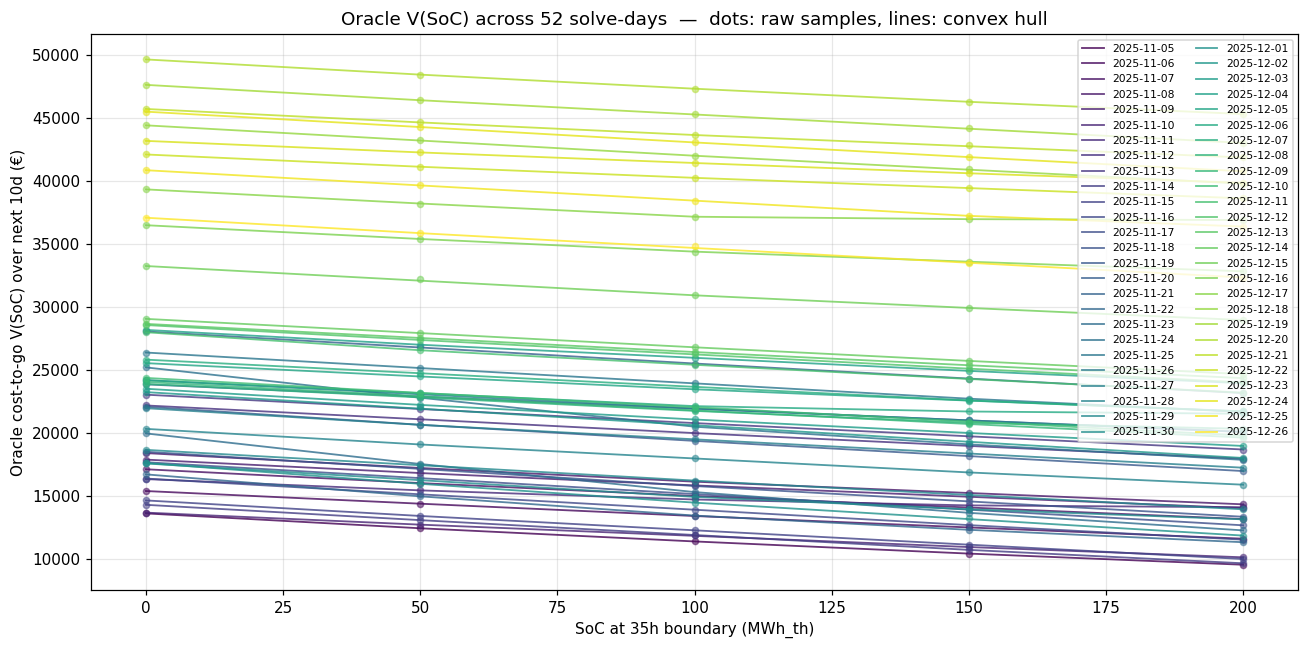


Marginal value of stored heat at SoC=100 (approx, from convex hull):
  2025-11-05: dV/dSoC ≈  20.91 €/MWh_th  (V@0=13594, V@200=9520)
  2025-11-06: dV/dSoC ≈  19.55 €/MWh_th  (V@0=15371, V@200=11587)
  2025-11-07: dV/dSoC ≈  20.42 €/MWh_th  (V@0=17098, V@200=13146)
  2025-11-08: dV/dSoC ≈  21.73 €/MWh_th  (V@0=18383, V@200=14315)
  2025-11-09: dV/dSoC ≈  19.62 €/MWh_th  (V@0=17865, V@200=14014)
  2025-11-10: dV/dSoC ≈  17.79 €/MWh_th  (V@0=13657, V@200=10108)
  2025-11-11: dV/dSoC ≈  14.49 €/MWh_th  (V@0=16318, V@200=14085)
  2025-11-12: dV/dSoC ≈  21.94 €/MWh_th  (V@0=22164, V@200=17937)
  2025-11-13: dV/dSoC ≈  22.36 €/MWh_th  (V@0=23021, V@200=18668)
  2025-11-14: dV/dSoC ≈  23.61 €/MWh_th  (V@0=14276, V@200=9634)
  2025-11-15: dV/dSoC ≈  22.79 €/MWh_th  (V@0=14625, V@200=9973)
  2025-11-16: dV/dSoC ≈  24.45 €/MWh_th  (V@0=16362, V@200=11508)
  2025-11-17: dV/dSoC ≈  25.26 €/MWh_th  (V@0=17658, V@200=12649)
  2025-11-18: dV/dSoC ≈  27.21 €/MWh_th  (V@0=18490, V@200=13328)
  2025-11

In [12]:
# Plot 1: V(SoC) curves for all solve-days — overlay to show seasonality/shape
fig, ax = plt.subplots(figsize=(12, 6))
cmap = plt.get_cmap('viridis')
v_cache = main_res['v_cache']
for i, v in enumerate(v_cache):
    color = cmap(i / max(1, len(v_cache)-1))
    ax.plot(v['bps_raw'], v['vals_raw'], 'o', color=color, alpha=0.5, markersize=4)
    ax.plot(v['bps_hull'], v['vals_hull'], '-', color=color, alpha=0.8, linewidth=1.2,
             label=f"{v['solve_day']}")
ax.set_xlabel('SoC at 35h boundary (MWh_th)')
ax.set_ylabel(f'Oracle cost-to-go V(SoC) over next {MAIN_FORWARD}d (€)')
ax.set_title(f'Oracle V(SoC) across {len(v_cache)} solve-days  —  dots: raw samples, lines: convex hull')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=7, loc='upper right', ncol=2)
plt.tight_layout(); plt.show()

# Summary: marginal value at SoC=100 (€/MWh_th)
print('\nMarginal value of stored heat at SoC=100 (approx, from convex hull):')
for v in v_cache:
    xh, yh = v['bps_hull'], v['vals_hull']
    # slope of the hull segment containing 100
    for i in range(len(xh)-1):
        if xh[i] <= 100 <= xh[i+1]:
            slope = (yh[i+1] - yh[i]) / (xh[i+1] - xh[i])
            print(f"  {v['solve_day']}: dV/dSoC ≈ {-slope:>6.2f} €/MWh_th  (V@0={yh[0]:.0f}, V@200={yh[-1]:.0f})")
            break


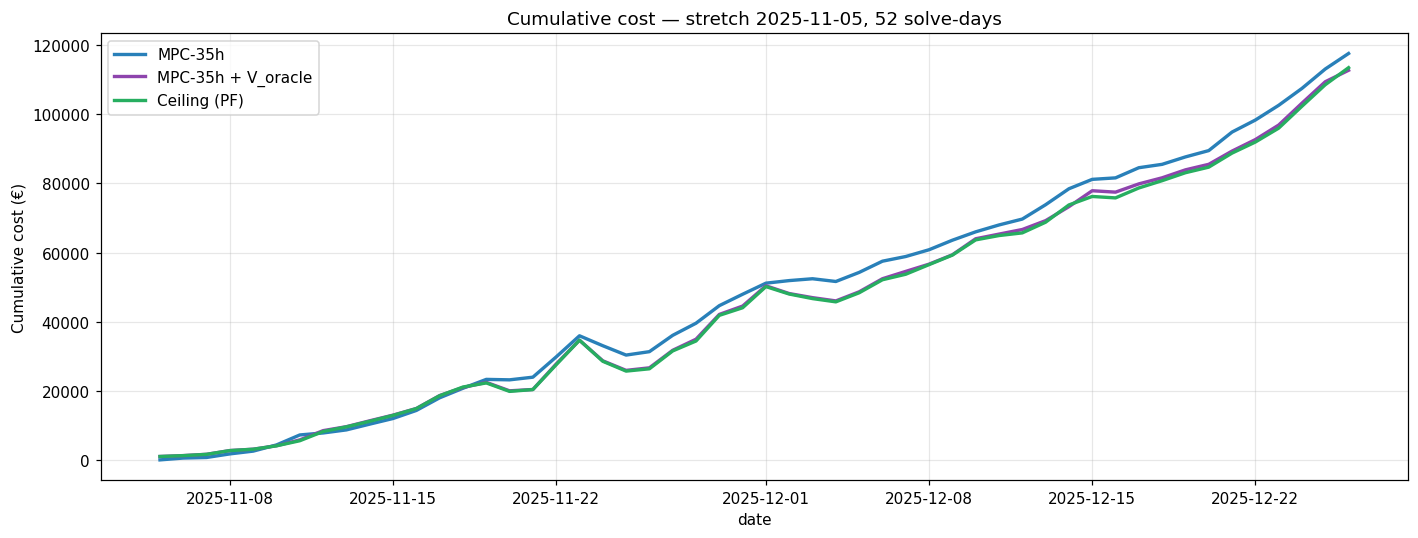

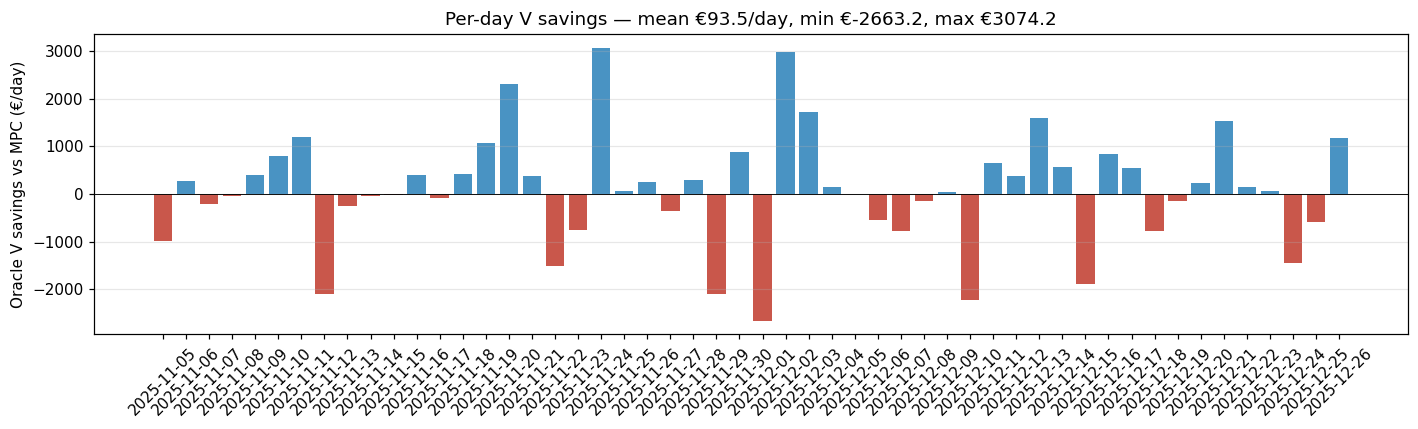

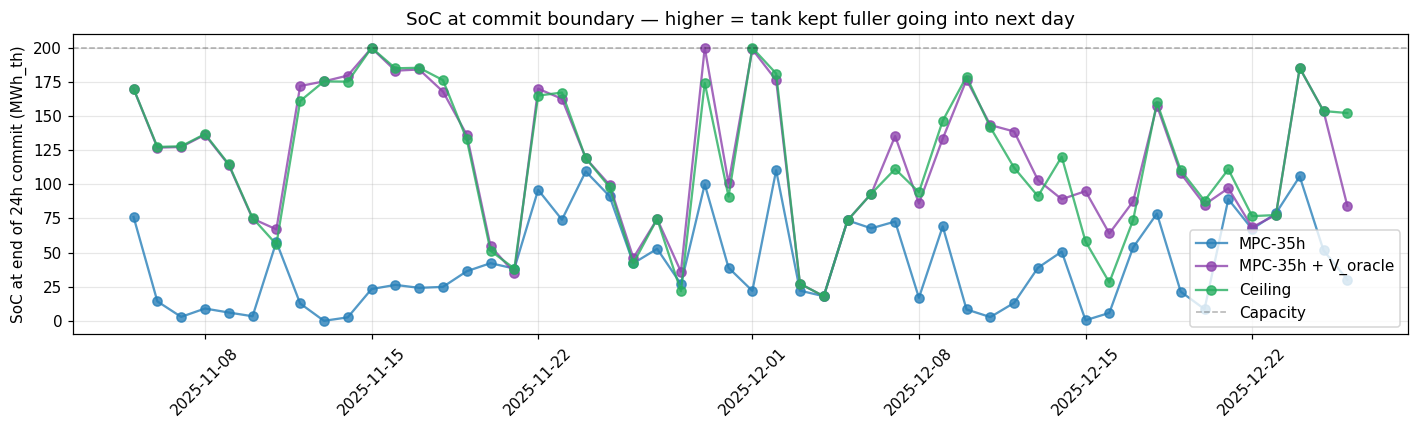

In [13]:
# Plot 2: cumulative cost — MPC vs MPC+V vs ceiling
fig, ax = plt.subplots(figsize=(13, 5))
for df, label, color in [(mpc_sub, 'MPC-35h', '#2980b9'),
                           (v_sub, 'MPC-35h + V_oracle', '#8e44ad'),
                           (ceil_sub, 'Ceiling (PF)', '#27ae60')]:
    d = df.sort_values('date').copy()
    d['cum'] = d['cost_total'].cumsum()
    ax.plot(d['date'], d['cum'], label=label, color=color, linewidth=2.2)
ax.set_xlabel('date'); ax.set_ylabel('Cumulative cost (€)')
ax.set_title(f'Cumulative cost — stretch {MAIN_STRETCH.start}, {n} solve-days')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Plot 3: per-day V savings bar chart, colored by sign
fig, ax = plt.subplots(figsize=(13, 4))
svg = cmp['v_savings'].values
colors = ['#2980b9' if x >= 0 else '#c0392b' for x in svg]
ax.bar(cmp['date'].astype(str), svg, color=colors, alpha=0.85)
ax.axhline(0, color='k', linewidth=0.6)
ax.set_ylabel('Oracle V savings vs MPC (€/day)')
ax.set_title(f'Per-day V savings — mean €{svg.mean():.1f}/day, min €{svg.min():.1f}, max €{svg.max():.1f}')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

# Plot 4: SoC at commit boundary — does V keep the tank fuller?
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(cmp['date'], cmp['soc_mpc'], 'o-', color='#2980b9', label='MPC-35h', alpha=0.8)
ax.plot(cmp['date'], cmp['soc_v'], 'o-', color='#8e44ad', label='MPC-35h + V_oracle', alpha=0.8)
ax.plot(cmp['date'], cmp['soc_ceil'], 'o-', color='#27ae60', label='Ceiling', alpha=0.8)
ax.axhline(200, color='k', alpha=0.3, linewidth=1, linestyle='--', label='Capacity')
ax.set_ylabel('SoC at end of 24h commit (MWh_th)')
ax.set_title('SoC at commit boundary — higher = tank kept fuller going into next day')
ax.legend(); ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()


## 8. Interpretation

Fill in after running the main cell. The three decision cases:

| Gap recovered by oracle V | Interpretation | Next step |
|---|---|---|
| **>70%** | V is a strong lever. Learning a good V should recover most of the residual gap. | Step 2: fit V(SoC \| month, context) from existing ceiling data and historical sweeps. Evaluate on holdout. |
| **30–70%** | V closes a meaningful share but not all of it. The unit-state-at-boundary dimension may matter. | Step 2 with extended state `V(SoC, z_chp_0, chp_tis_0)`, or extend forward window to tighten the upper bound. |
| **<30%** | V can't fix this. The residual gap is in things V doesn't see — ceiling-block artefacts, longer-than-forward_days lookahead, or unit-state coupling. | Revisit: longer forward window, chained-SoC ceiling, or accept that MPC-35h is near the operational ceiling under no-EPF constraints. |

**Bias to keep in mind.** This is an optimistic bound:
- Perfect foresight inside V
- V perfectly re-fit at every solve-day (a deployed V would be learned once, applied many times)
- No demand-forecast noise

A learned V under realistic noise will deliver <this number. If the oracle is weak (<30%), no learned V will save you.
